# Pose Detection — Standalone Demo

Isolates the pose estimation step from the main pipeline.

**Handles both MediaPipe API generations automatically:**

| Version | API | Entry point |
|---|---|---|
| ≤ 0.10.13 | Legacy Solutions | `mp.solutions.pose.Pose` |
| ≥ 0.10.14 | Tasks API | `mp.tasks.python.vision.PoseLandmarker` |

The Tasks API requires a `.task` model file — this notebook downloads `pose_landmarker_lite.task` (~5 MB) automatically.

**Output**: for each detected person, the 33 body landmarks plus the 4 joints used by the main pipeline — left/right hips (indices 23/24) and left/right ankles (27/28).

## 1 — Install & detect MediaPipe generation

In [14]:
%pip install -q mediapipe opencv-python-headless numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [15]:
import importlib, urllib.request, pathlib, textwrap
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import mediapipe as mp

MP_VERSION = tuple(int(x) for x in mp.__version__.split(".")[:3])
print(f"MediaPipe {mp.__version__}  →  ", end="")

# ── Detect which API generation is available ──────────────────────────────────
def _has_solutions() -> bool:
    try:
        _ = mp.solutions.pose
        return True
    except AttributeError:
        pass
    try:
        from mediapipe.python.solutions import pose  # noqa: F401
        return True
    except (ImportError, ModuleNotFoundError):
        return False

def _has_tasks() -> bool:
    try:
        from mediapipe.tasks.python import vision  # noqa: F401
        return True
    except (ImportError, ModuleNotFoundError):
        return False

USE_TASKS     = not _has_solutions() and _has_tasks()
USE_SOLUTIONS = _has_solutions()

if USE_SOLUTIONS:
    print("legacy Solutions API")
elif USE_TASKS:
    print("Tasks API (0.10.14+)")
else:
    raise RuntimeError(
        "No usable MediaPipe pose backend found.\n"
        "Try: pip install 'mediapipe>=0.10.14'"
    )

MediaPipe 0.10.35  →  Tasks API (0.10.14+)


## 2 — Download model (Tasks API only)

The Tasks API needs an explicit `.task` model file. The lite model is ~5 MB and is downloaded once; subsequent runs reuse the cached file.

In [16]:
MODEL_PATH = pathlib.Path("pose_landmarker_lite.task")
MODEL_URL  = (
    "https://storage.googleapis.com/mediapipe-models/"
    "pose_landmarker/pose_landmarker_lite/float16/latest/"
    "pose_landmarker_lite.task"
)

if USE_TASKS:
    if not MODEL_PATH.exists():
        print(f"Downloading {MODEL_URL} …")
        urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
        print(f"Saved → {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1e6:.1f} MB)")
    else:
        print(f"Model already cached: {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1e6:.1f} MB)")
else:
    print("Using Solutions API — no model download needed.")

Model already cached: pose_landmarker_lite.task  (5.8 MB)


## 3 — Build the detector

A single `detect(frame_bgr)` function works regardless of API generation.  Returns a list of per-person landmark arrays `(33, 4)` — columns are `[x_norm, y_norm, z_norm, visibility]` in normalised image coordinates (0–1).

In [17]:
# ── MediaPipe landmark indices we care about ──────────────────────────────────
LM = {
    "nose":         0,
    "left_shoulder": 11, "right_shoulder": 12,
    "left_elbow":   13,  "right_elbow":    14,
    "left_wrist":   15,  "right_wrist":    16,
    "left_hip":     23,  "right_hip":      24,
    "left_knee":    25,  "right_knee":     26,
    "left_ankle":   27,  "right_ankle":    28,
    "left_heel":    29,  "right_heel":     30,
    "left_toe":     31,  "right_toe":      32,
}

SKELETON_EDGES = [
    (LM["nose"],         LM["left_shoulder"]),
    (LM["nose"],         LM["right_shoulder"]),
    (LM["left_shoulder"],LM["right_shoulder"]),
    (LM["left_shoulder"],LM["left_elbow"]),
    (LM["right_shoulder"],LM["right_elbow"]),
    (LM["left_elbow"],   LM["left_wrist"]),
    (LM["right_elbow"],  LM["right_wrist"]),
    (LM["left_shoulder"],LM["left_hip"]),
    (LM["right_shoulder"],LM["right_hip"]),
    (LM["left_hip"],     LM["right_hip"]),
    (LM["left_hip"],     LM["left_knee"]),
    (LM["right_hip"],    LM["right_knee"]),
    (LM["left_knee"],    LM["left_ankle"]),
    (LM["right_knee"],   LM["right_ankle"]),
]

# ── Unified detector ──────────────────────────────────────────────────────────

if USE_SOLUTIONS:
    # Legacy path — build once, keep alive
    try:
        _pose_mod = mp.solutions.pose
    except AttributeError:
        from mediapipe.python.solutions import pose as _pose_mod

    _solver = _pose_mod.Pose(
        static_image_mode=True,
        model_complexity=1,
        enable_segmentation=False,
        min_detection_confidence=0.3,
    )

    def detect(frame_bgr: np.ndarray) -> list[np.ndarray]:
        """Returns list of (33,4) landmark arrays for each detected person."""
        rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        res = _solver.process(rgb)
        if res.pose_landmarks is None:
            return []
        lm = res.pose_landmarks.landmark
        arr = np.array([[l.x, l.y, l.z, l.visibility] for l in lm], dtype=np.float32)
        return [arr]

elif USE_TASKS:
    from mediapipe.tasks import python as _mp_python
    from mediapipe.tasks.python import vision as _mp_vision

    _base_opts = _mp_python.BaseOptions(model_asset_path=str(MODEL_PATH))
    _task_opts = _mp_vision.PoseLandmarkerOptions(
        base_options=_base_opts,
        num_poses=2,
        min_pose_detection_confidence=0.3,
        min_pose_presence_confidence=0.3,
        min_tracking_confidence=0.3,
        output_segmentation_masks=False,
    )
    _landmarker = _mp_vision.PoseLandmarker.create_from_options(_task_opts)

    def detect(frame_bgr: np.ndarray) -> list[np.ndarray]:
        """Returns list of (33,4) landmark arrays — one per detected person."""
        rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = _landmarker.detect(mp_img)
        out = []
        for person_lms in result.pose_landmarks:
            arr = np.array(
                [[l.x, l.y, l.z, l.visibility] for l in person_lms],
                dtype=np.float32,
            )
            out.append(arr)
        return out

print("Detector ready.")

I0000 00:00:1780588983.037970 1899248 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1780588983.047790 1899265 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: AMD Radeon 760M Graphics (radeonsi, phoenix, LLVM 20.1.2, DRM 3.64, 6.17.0-20-generic)
W0000 00:00:1780588983.103480 1899253 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1780588983.128594 1899252 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Detector ready.


## 4 — Load a test image

Tries three sources in order:
1. Any `.jpg` / `.png` already in the working directory
2. A freely-licensed stock photo downloaded from the web
3. A plain green rectangle as a last resort (no person will be detected — useful for testing the "no detection" path)

Loaded pose1.jpeg  —  shape: (427, 640, 3)


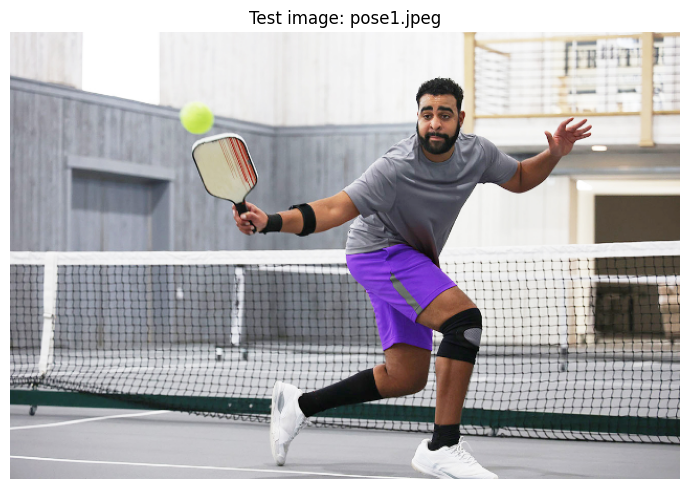

In [18]:
TEST_IMAGE_PATH = "pose1.jpeg"

frame_bgr = cv2.imread(TEST_IMAGE_PATH)
if frame_bgr is None:
    raise FileNotFoundError(f"Could not load {TEST_IMAGE_PATH}")

# Resize to max 640px wide for speed
h, w = frame_bgr.shape[:2]
if w > 640:
    scale = 640 / w
    frame_bgr = cv2.resize(frame_bgr, (640, int(h * scale)))
print(f"Loaded {TEST_IMAGE_PATH}  —  shape: {frame_bgr.shape}")

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
plt.title(f"Test image: {TEST_IMAGE_PATH}")
plt.axis("off")
plt.tight_layout()
plt.show()

## 5 — Run detection & visualise landmarks

Detected 1 person(s).


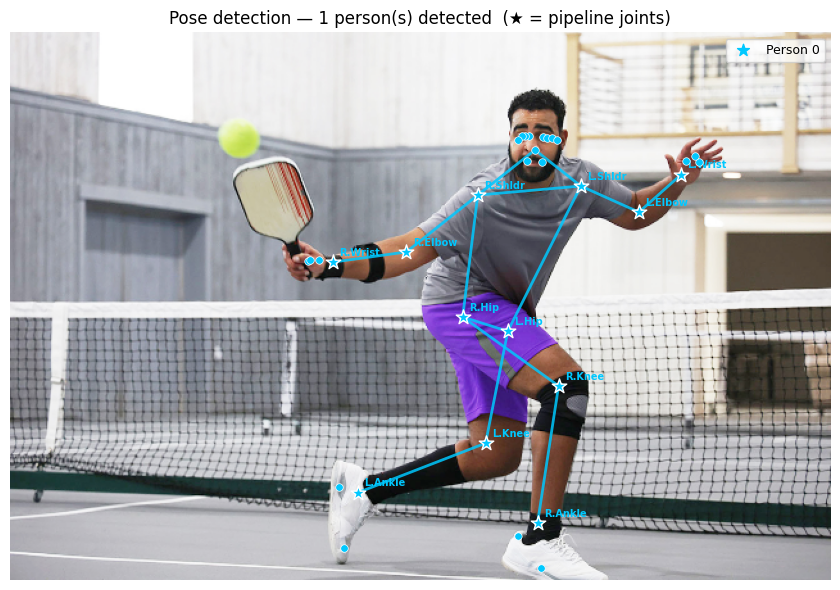

In [19]:
people = detect(frame_bgr)
print(f"Detected {len(people)} person(s).")

h, w = frame_bgr.shape[:2]
PERSON_COLORS = ["#00C8FF", "#FF8200", "#00E676", "#FF4081"]

def draw_landmarks(ax, lm_arr: np.ndarray, color: str, label: str) -> None:
    """Draw skeleton edges and landmark dots on a matplotlib axes."""
    vis_thresh = 0.3

    # Skeleton edges
    for i, j in SKELETON_EDGES:
        if lm_arr[i, 3] >= vis_thresh and lm_arr[j, 3] >= vis_thresh:
            xs = [lm_arr[i, 0] * w, lm_arr[j, 0] * w]
            ys = [lm_arr[i, 1] * h, lm_arr[j, 1] * h]
            ax.plot(xs, ys, "-", color=color, lw=2, alpha=0.85)

    # All landmark dots (sized by visibility)
    for idx in range(33):
        vis = lm_arr[idx, 3]
        if vis < vis_thresh:
            continue
        px, py = lm_arr[idx, 0] * w, lm_arr[idx, 1] * h
        ax.scatter(px, py, s=30 * vis, color=color, zorder=5, edgecolors="white", lw=0.5)

    # Highlight pipeline joints with a star
    pipeline_labels = {
        11: "L.Shldr", 12: "R.Shldr",
        13: "L.Elbow", 14: "R.Elbow",
        15: "L.Wrist", 16: "R.Wrist",
        23: "L.Hip",   24: "R.Hip",
        25: "L.Knee",  26: "R.Knee",
        27: "L.Ankle", 28: "R.Ankle",
    }
    for idx, name in pipeline_labels.items():
        if lm_arr[idx, 3] >= vis_thresh:
            px, py = lm_arr[idx, 0] * w, lm_arr[idx, 1] * h
            ax.scatter(px, py, s=120, color=color, marker="*", zorder=6,
                       edgecolors="white", lw=1)
            ax.text(px + 5, py - 5, name, color=color, fontsize=7, fontweight="bold")

    ax.scatter([], [], color=color, marker="*", s=80, label=label)


fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB))
ax.set_title(f"Pose detection — {len(people)} person(s) detected  (★ = pipeline joints)")

if not people:
    ax.text(
        0.5, 0.5,
        "No person detected.\nTry a clearer full-body photo.",
        transform=ax.transAxes, ha="center", va="center",
        fontsize=14, color="white",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#333", alpha=0.8),
    )
else:
    for i, lm_arr in enumerate(people):
        col = PERSON_COLORS[i % len(PERSON_COLORS)]
        draw_landmarks(ax, lm_arr, color=col, label=f"Person {i}")
    ax.legend(loc="upper right", fontsize=9)

ax.axis("off")
plt.tight_layout()
plt.show()

## 6 — Extract pipeline-relevant joints

The main pipeline needs exactly four values per player: the foot position (ankle midpoint) and hip midpoint, both in pixel coordinates. This cell shows how to extract them and prints a confidence summary.

In [20]:
from dataclasses import dataclass

@dataclass
class PoseResult:
    player_id:      int
    foot_pixel:     tuple[float, float]   # ankle midpoint
    hip_pixel:      tuple[float, float]   # hip midpoint
    shoulder_pixel: tuple[float, float]   # shoulder midpoint
    elbow_l_pixel:  tuple[float, float]
    elbow_r_pixel:  tuple[float, float]
    wrist_l_pixel:  tuple[float, float]
    wrist_r_pixel:  tuple[float, float]
    knee_l_pixel:   tuple[float, float]
    knee_r_pixel:   tuple[float, float]
    confidence:     float                 # min visibility across all pipeline joints


CONFIDENCE_THRESHOLD = 0.50


def landmarks_to_pose_result(player_id: int, lm_arr: np.ndarray,
                              img_h: int, img_w: int) -> PoseResult:
    """Convert a (33,4) landmark array to a PoseResult for the main pipeline."""
    L_SHLDR, R_SHLDR = 11, 12
    L_ELBOW, R_ELBOW = 13, 14
    L_WRIST, R_WRIST = 15, 16
    L_HIP,   R_HIP   = 23, 24
    L_KNEE,  R_KNEE  = 25, 26
    L_ANKLE, R_ANKLE = 27, 28

    def px(idx):
        return lm_arr[idx, 0] * img_w, lm_arr[idx, 1] * img_h

    lhip,   rhip   = px(L_HIP),   px(R_HIP)
    lankle, rankle = px(L_ANKLE), px(R_ANKLE)
    lshldr, rshldr = px(L_SHLDR), px(R_SHLDR)

    foot_pixel     = ((lankle[0] + rankle[0]) / 2, (lankle[1] + rankle[1]) / 2)
    hip_pixel      = ((lhip[0]   + rhip[0])   / 2, (lhip[1]   + rhip[1])   / 2)
    shoulder_pixel = ((lshldr[0] + rshldr[0]) / 2, (lshldr[1] + rshldr[1]) / 2)

    pipeline_indices = [
        L_SHLDR, R_SHLDR, L_ELBOW, R_ELBOW,
        L_WRIST, R_WRIST, L_HIP,   R_HIP,
        L_KNEE,  R_KNEE,  L_ANKLE, R_ANKLE,
    ]
    confidence = float(min(lm_arr[i, 3] for i in pipeline_indices))

    return PoseResult(
        player_id=player_id,
        foot_pixel=foot_pixel,
        hip_pixel=hip_pixel,
        shoulder_pixel=shoulder_pixel,
        elbow_l_pixel=px(L_ELBOW),
        elbow_r_pixel=px(R_ELBOW),
        wrist_l_pixel=px(L_WRIST),
        wrist_r_pixel=px(R_WRIST),
        knee_l_pixel=px(L_KNEE),
        knee_r_pixel=px(R_KNEE),
        confidence=confidence,
    )


# ── Extract results ────────────────────────────────────────────────────────────
h, w = frame_bgr.shape[:2]
pose_results = [
    landmarks_to_pose_result(i, lm_arr, h, w)
    for i, lm_arr in enumerate(people)
]

print(f"{'Player':<8} {'Foot pixel (x,y)':<24} {'Hip pixel (x,y)':<24} {'Shoulder (x,y)':<24} {'Conf':>6}  {'Status'}")
print("─" * 100)
for pr in pose_results:
    status = "OK" if pr.confidence >= CONFIDENCE_THRESHOLD else "LOW CONF — abstain"
    print(
        f"  {pr.player_id:<6} "
        f"({pr.foot_pixel[0]:6.1f},{pr.foot_pixel[1]:6.1f})        "
        f"({pr.hip_pixel[0]:6.1f},{pr.hip_pixel[1]:6.1f})        "
        f"({pr.shoulder_pixel[0]:6.1f},{pr.shoulder_pixel[1]:6.1f})        "
        f"{pr.confidence:.3f}  {status}"
    )
    print(f"          elbows  L({pr.elbow_l_pixel[0]:6.1f},{pr.elbow_l_pixel[1]:6.1f})  "
          f"R({pr.elbow_r_pixel[0]:6.1f},{pr.elbow_r_pixel[1]:6.1f})   "
          f"wrists  L({pr.wrist_l_pixel[0]:6.1f},{pr.wrist_l_pixel[1]:6.1f})  "
          f"R({pr.wrist_r_pixel[0]:6.1f},{pr.wrist_r_pixel[1]:6.1f})")
    print(f"          knees   L({pr.knee_l_pixel[0]:6.1f},{pr.knee_l_pixel[1]:6.1f})  "
          f"R({pr.knee_r_pixel[0]:6.1f},{pr.knee_r_pixel[1]:6.1f})")

if not pose_results:
    print("  (no detections)")

print()
print("foot_pixel feeds into warp_to_court(); shoulder/elbow/wrist/knee available for posture features.")

Player   Foot pixel (x,y)         Hip pixel (x,y)          Shoulder (x,y)             Conf  Status
────────────────────────────────────────────────────────────────────────────────────────────────────
  0      ( 340.6, 370.3)        ( 370.0, 227.0)        ( 404.4, 122.9)        0.953  OK
          elbows  L( 489.9, 139.7)  R( 308.6, 170.7)   wrists  L( 522.7, 110.4)  R( 251.0, 178.7)
          knees   L( 370.3, 319.8)  R( 427.2, 275.2)

foot_pixel feeds into warp_to_court(); shoulder/elbow/wrist/knee available for posture features.


## 7 — Visibility heatmap

Visualises per-landmark visibility scores for all detected people. Low-visibility joints are the main source of uncertainty — the abstention layer in `demo.ipynb` uses the ankle/hip minimum as the per-player confidence gate.

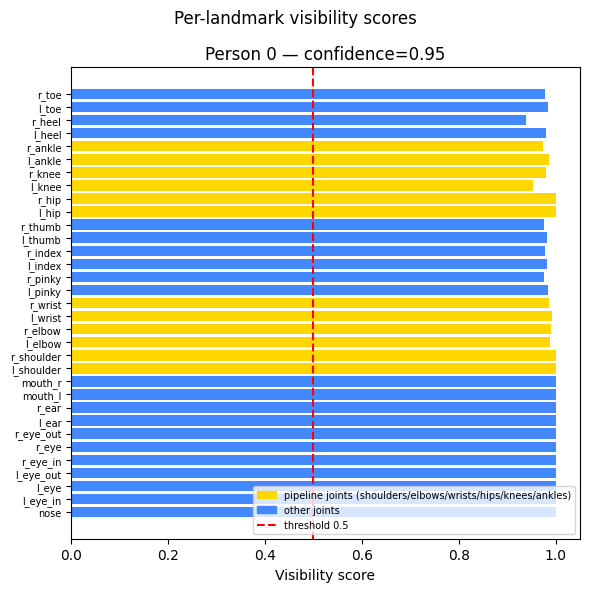

In [21]:
LM_NAMES = [
    "nose","l_eye_in","l_eye","l_eye_out","r_eye_in","r_eye","r_eye_out",
    "l_ear","r_ear","mouth_l","mouth_r",
    "l_shoulder","r_shoulder","l_elbow","r_elbow","l_wrist","r_wrist",
    "l_pinky","r_pinky","l_index","r_index","l_thumb","r_thumb",
    "l_hip","r_hip","l_knee","r_knee","l_ankle","r_ankle",
    "l_heel","r_heel","l_toe","r_toe",
]

PIPELINE_JOINTS = {
    11, 12,   # shoulders
    13, 14,   # elbows
    15, 16,   # wrists
    23, 24,   # hips
    25, 26,   # knees
    27, 28,   # ankles
}

if not people:
    print("No detections — nothing to plot.")
else:
    n = len(people)
    fig, axes = plt.subplots(1, n, figsize=(max(6, 5 * n), 6), squeeze=False)
    for i, (lm_arr, ax) in enumerate(zip(people, axes[0])):
        vis = lm_arr[:, 3]
        colors = ["#FFD700" if idx in PIPELINE_JOINTS else "#4488FF"
                  for idx in range(33)]
        bars = ax.barh(range(33), vis, color=colors, edgecolor="none", height=0.8)
        ax.axvline(CONFIDENCE_THRESHOLD, color="red", lw=1.5, ls="--",
                   label=f"threshold ({CONFIDENCE_THRESHOLD})")
        ax.set_yticks(range(33))
        ax.set_yticklabels(LM_NAMES, fontsize=7)
        ax.set_xlim(0, 1.05)
        ax.set_xlabel("Visibility score")
        ax.set_title(f"Person {i} — confidence={pose_results[i].confidence:.2f}")
        ax.legend(fontsize=8)

        # Highlight pipeline joints
        gold_patch  = mpatches.Patch(color="#FFD700", label="pipeline joints (shoulders/elbows/wrists/hips/knees/ankles)")
        blue_patch  = mpatches.Patch(color="#4488FF", label="other joints")
        ax.legend(handles=[gold_patch, blue_patch,
                            plt.Line2D([0],[0],color="red",ls="--",label=f"threshold {CONFIDENCE_THRESHOLD}")],
                  fontsize=7, loc="lower right")

    plt.suptitle("Per-landmark visibility scores", fontsize=12)
    plt.tight_layout()
    plt.show()

## 8 — Run on your own image

Drop any image file into the working directory and re-run from Cell 4. Or pass a path directly:

In [ ]:
def run_on_image(path: str) -> None:
    img = cv2.imread(path)
    if img is None:
        print(f"Could not load {path}")
        return
    h, w = img.shape[:2]
    if w > 800:
        img = cv2.resize(img, (800, int(h * 800 / w)))

    people = detect(img)
    print(f"{path}  →  {len(people)} person(s) detected")
    for i, lm_arr in enumerate(people):
        pr = landmarks_to_pose_result(i, lm_arr, *img.shape[:2])
        status = "OK" if pr.confidence >= CONFIDENCE_THRESHOLD else "LOW CONF"
        print(f"  P{i}  foot={pr.foot_pixel}  conf={pr.confidence:.2f}  {status}")

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    for i, lm_arr in enumerate(people):
        draw_landmarks(ax, lm_arr, PERSON_COLORS[i % len(PERSON_COLORS)], f"P{i}")
    ax.set_title(f"{path} — {len(people)} person(s)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# Example:
# run_on_image("my_court_photo.jpg")